In [1]:
import pandas as pd
import os
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
import json
import ast

In [2]:
def rpy_to_rotmat(rpy):
    """
    rpy: (..., 3) roll, pitch, yaw
    returns: (..., 3, 3) rotation matrix (base -> world)
    """
    roll, pitch, yaw = rpy[..., 0], rpy[..., 1], rpy[..., 2]

    cr, sr = np.cos(roll),  np.sin(roll)
    cp, sp = np.cos(pitch), np.sin(pitch)
    cy, sy = np.cos(yaw),   np.sin(yaw)

    R = np.stack([
        np.stack([cy*cp, cy*sp*sr - sy*cr, cy*sp*cr + sy*sr], axis=-1),
        np.stack([sy*cp, sy*sp*sr + cy*cr, sy*sp*cr - cy*sr], axis=-1),
        np.stack([-sp,   cp*sr,            cp*cr           ], axis=-1)
    ], axis=-2)

    return R


In [3]:
# Define a function to convert the string representation of an array/list
def string_to_array(array_string):
    try:
        # Use ast.literal_eval to safely evaluate the string as a Python literal
        return ast.literal_eval(array_string)
    except (ValueError, SyntaxError):
        # Handle cases where the string might not be a valid list/array string
        return array_string # Or some default/error value

In [4]:
exp_filepath = "exp_data/initial_corl_test/pact_plane_6-12kg.csv"

df = pd.read_csv(exp_filepath, converters={'base_cmd': string_to_array,
                                           'base_pose': string_to_array,
                                           'base_rpy': string_to_array,
                                           'dof_pose': string_to_array,
                                           'base_lin_vel': string_to_array,
                                           'base_ang_vel': string_to_array,
                                           'dof_vel': string_to_array,
                                           'proj_grav': string_to_array,
                                           'feet_pos': string_to_array,
                                           'tau_act': string_to_array,
                                           'grf': string_to_array,
                                           'q_des': string_to_array,
                                           'tau_ff': string_to_array,
                                           'tau_pd': string_to_array,
                                           'failure': string_to_array})

print(len(df))

1010000


In [5]:
# Joint tracking / violation metrics
q_actions      = np.array(df.loc[df["failure"] == 0, "q_des"].to_list())
q_observations = np.array(df.loc[df["failure"] == 0, "dof_pose"].to_list())

# cmd tracking metrics
vel_cmds = np.array(df.loc[df["failure"] == 0, "base_cmd"].to_list())  # v_x, v_y, w_yaw
lin_vel  = np.array(df.loc[df["failure"] == 0, "base_lin_vel"].to_list())
ang_vel  = np.array(df.loc[df["failure"] == 0, "base_ang_vel"].to_list())   # stability via roll/pitch angular velo.

# Height tracking metric
base_pose = np.array(df.loc[df["failure"] == 0, "base_pose"].to_list())
base_rpy = np.array(df.loc[df["failure"] == 0, "base_rpy"].to_list())

R_w_b = rpy_to_rotmat(base_rpy)

# Oreintation
proj_grav = np.array(df.loc[df["failure"] == 0, "proj_grav"].to_list())

# joint power metric
q_vel = np.array(df.loc[df["failure"] == 0, "dof_vel"].to_list())
q_tau = np.array(df.loc[df["failure"] == 0, "tau_act"].to_list())

# alignment metric, ratio metric
ff_tau = np.array(df.loc[df["failure"] == 0, "tau_ff"].to_list())
pd_tau = np.array(df.loc[df["failure"] == 0, "tau_pd"].to_list())

grfs = np.array(df.loc[df["failure"] == 0, "grf"].to_list())

joint_limits = np.array([[-1.047, -0.633, -2.721, -1.047, -0.633, -2.721, -1.047, -0.633, -2.721, -1.047, -0.633, -2.721],
                         [1.047, 2.966, -0.837, 1.047, 2.966, -0.837, 1.047, 2.966, -0.837, 1.047, 2.966, -0.837]])

joint_torque_limits = np.array([23.7, 23.7, 35.55, 23.7, 23.7, 35.55, 23.7, 23.7, 35.55, 23.7, 23.7, 35.55])

In [6]:
print("Number of failures: ", df["failure"].sum())

Number of failures:  11


In [7]:
dof_errors = q_actions - q_observations
print("DOF Tracking RMSE: ", np.round(np.sqrt(np.mean(np.square(dof_errors))),4))

DOF Tracking RMSE:  0.1827


In [8]:
lin_cmd_errors = vel_cmds[:,0:2] - lin_vel[:,0:2]
ang_cmd_errors = vel_cmds[:,2] - ang_vel[:,2]

cmd_errs = np.concatenate((lin_cmd_errors, ang_cmd_errors[:,None]), axis=1)

print(cmd_errs.shape)

print("Linear CMD Tracking  RMSE: ", np.round(np.sqrt(np.mean(np.square(lin_cmd_errors))),4))
print("Linear CMD Tracking STDDV: ", np.round(np.sqrt(np.std(np.square(lin_cmd_errors))),4))
print("Linear CMD Tracking  MAE: ", np.round(np.mean(np.abs(lin_cmd_errors)),4))


print("Angular CMD Tracking  RMSE: ", np.round(np.sqrt(np.mean(np.square(ang_cmd_errors))),4))
print("Angular CMD Tracking STDDV: ", np.round(np.sqrt(np.std(np.square(ang_cmd_errors))),4))
print("Angular CMD Tracking  MAE: ", np.round(np.mean(np.abs(ang_cmd_errors)),4))


print("Total CMD Tracking  RMSE: ", np.round(np.sqrt(np.mean(np.square(cmd_errs))),4))
print("Total CMD Tracking  STDDV: ", np.round(np.sqrt(np.std(np.square(cmd_errs))),4))

(1009989, 3)
Linear CMD Tracking  RMSE:  0.1996
Linear CMD Tracking STDDV:  0.3823
Linear CMD Tracking  MAE:  0.1296
Angular CMD Tracking  RMSE:  0.2239
Angular CMD Tracking STDDV:  0.4345
Angular CMD Tracking  MAE:  0.1675
Total CMD Tracking  RMSE:  0.208
Total CMD Tracking  STDDV:  0.4021


In [9]:
height_errors = 0.30 - base_pose[:,2]

print("Height CMD Tracking  RMSE: ", np.round(np.sqrt(np.mean(np.square(height_errors))),4))

Height CMD Tracking  RMSE:  0.0231


In [10]:
orientation_norm = np.linalg.norm(proj_grav[:,0:2], axis=1)

print("Projected Grav. R/P Norm: ", np.round(np.mean(orientation_norm),4))

Projected Grav. R/P Norm:  0.0566


In [11]:
velo_z = lin_vel[:,2]
ang_velo_norm = np.linalg.norm(ang_vel[:,0:2], axis=1)

print("Angular Velo. R/P Norm MEAN: ", np.round(np.mean(ang_velo_norm),4))
print("Angular Velo. R/P Norm STD: ", np.round(np.std(ang_velo_norm),4))

print("Z Velo. MEAN: ", np.round(np.sqrt(np.mean(np.square(velo_z))),4))
print("Z Velo. STD: ", np.round(np.sqrt(np.std(np.square(velo_z))),4))
print("Z Velo. MEAN: ", np.round(np.mean(np.abs(velo_z)),4))


total_unwatnted_velo = np.concatenate((velo_z[:,None], ang_vel[:,0:2]), axis=1)

print("Total Velo. R/P Norm MEAN: ", np.round(np.mean(np.linalg.norm(total_unwatnted_velo, axis=1)),4))
print("Angular Velo. R/P Norm STD: ", np.round(np.std(np.linalg.norm(total_unwatnted_velo, axis=1)),4))

Angular Velo. R/P Norm MEAN:  0.5071
Angular Velo. R/P Norm STD:  0.3489
Z Velo. MEAN:  0.0753
Z Velo. STD:  0.1223
Z Velo. MEAN:  0.0556
Total Velo. R/P Norm MEAN:  0.514
Angular Velo. R/P Norm STD:  0.3469


In [12]:
joint_pred_limits_error = -(q_actions - joint_limits[0,:]).clip(max=0.0)
joint_pred_limits_error += (q_actions - joint_limits[1,:]).clip(min=0.0)

print("Avg. Joint Violation: ", np.mean(joint_pred_limits_error))

Avg. Joint Violation:  6.139417060309952e-06


In [13]:
total_tau_cmd = ff_tau + pd_tau
joint_torque_limits_violation = -(total_tau_cmd - (-joint_torque_limits)).clip(max=0.0)
joint_torque_limits_violation += (total_tau_cmd - joint_torque_limits).clip(min=0.0)

print("Avg. Joint Torque Violation: ", np.mean(joint_torque_limits_violation))

Avg. Joint Torque Violation:  0.03423110514289336


In [14]:
joint_energy = q_vel * q_tau

print("Observed Joint Energy Norm MEAN: ", np.round(np.mean(np.linalg.norm(joint_energy, axis=1)),4))
print("Observed Joint Energy Norm STD: ", np.round(np.std(np.linalg.norm(joint_energy, axis=1)),4))

Observed Joint Energy Norm MEAN:  30.4877
Observed Joint Energy Norm STD:  49.5188


In [15]:
print("Observed GRF Norm MEAN: ", np.round(np.mean(np.linalg.norm(grfs, axis=1)),4))
print("Observed GRF Norm STD: ", np.round(np.std(np.linalg.norm(grfs, axis=1)),4))

Observed GRF Norm MEAN:  172.0235
Observed GRF Norm STD:  37.3828


In [16]:
norm_q_actions = np.linalg.norm(q_actions, axis=1)
print("Q Action Magnitude MEAN: ", np.round(np.mean(norm_q_actions),4))
print("Q Action Magnitude STD: ", np.round(np.std(norm_q_actions),4))

Q Action Magnitude MEAN:  3.7521
Q Action Magnitude STD:  0.221


In [17]:
norm_q_actions = np.linalg.norm(pd_tau, axis=1)
print("Q Action Magnitude MEAN: ", np.round(np.mean(norm_q_actions),4))
print("Q Action Magnitude STD: ", np.round(np.std(norm_q_actions),4))

Q Action Magnitude MEAN:  17.0473
Q Action Magnitude STD:  3.6828


In [18]:
3.4817 - 3.6654

-0.18369999999999997

In [19]:
norm_q_actions = np.linalg.norm(ff_tau, axis=1)
print("Tau Action Magnitude MEAN: ", np.round(np.mean(norm_q_actions),4))
print("Tau Action Magnitude STD: ", np.round(np.std(norm_q_actions),4))

Tau Action Magnitude MEAN:  20.3292
Tau Action Magnitude STD:  3.6429


In [20]:
cosine_sim_scores = []

# for tau_ff_, tau_pd_, _q_vel in zip(ff_tau, pd_tau, q_vel):
#     dot = np.dot(tau_ff_*_q_vel, tau_pd_*_q_vel)
#     ff_norm = np.linalg.norm(tau_ff_*_q_vel)
#     pd_norm = np.linalg.norm(tau_pd_*_q_vel)

#     cosine_sim_scores.append((dot/(ff_norm * pd_norm + 1e-8)))

ff_power = ff_tau*q_vel
pd_power = pd_tau*q_vel
dot = np.sum(ff_power*pd_power, axis=1)
ff_power_norm = np.linalg.norm(ff_power, axis=1)
pd_power_norm = np.linalg.norm(pd_power, axis=1)

cosine_sim_scores = dot / ((ff_power_norm*pd_power_norm) + 1e-8)

print("Avg. Power Alignment - ", np.round(np.mean(cosine_sim_scores), 4))
print("STD. Power Alignment - ", np.round(np.std(cosine_sim_scores), 4))

Avg. Power Alignment -  0.7527
STD. Power Alignment -  0.2625


(array([   835.,   2787.,   4961.,   7888.,  13464.,  20530.,  38410.,
         83904., 241229., 595981.]),
 array([-0.98547471, -0.78698493, -0.58849515, -0.39000537, -0.19151559,
         0.00697419,  0.20546397,  0.40395375,  0.60244353,  0.8009333 ,
         0.99942308]),
 <BarContainer object of 10 artists>)

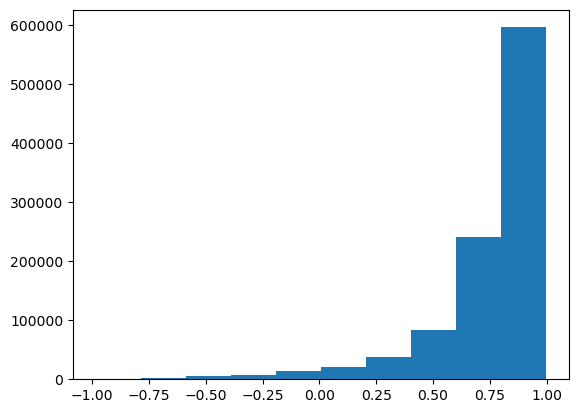

In [21]:
plt.hist(cosine_sim_scores)

In [22]:
numerator = np.sum(np.maximum(-dot, 0.0))
denominator = np.sum(np.abs(dot))

metric = numerator/denominator

print("Fraction of Antagonistic Energy, ", np.round(metric, 4))

Fraction of Antagonistic Energy,  0.0121


In [23]:
total_energy = (ff_tau + pd_tau) * q_vel

numerator = np.abs(ff_power) + np.abs(pd_power) - np.abs(total_energy)
denominator = np.abs(ff_power) + np.abs(pd_power)

cancel_metric = np.mean(numerator) / np.mean(denominator)
print("Internal Power Cancellation - ", np.round(cancel_metric, 4))

Internal Power Cancellation -  0.0662


In [24]:
ratio = np.mean(pd_power_norm) / np.mean(ff_power_norm)
print("Avg. Coupled Torque Ratio - ", np.round(ratio, 4))

Avg. Coupled Torque Ratio -  0.9643


In [25]:
print(np.mean(pd_power_norm))
print(np.mean(ff_power_norm))

38.28496276751928
39.70192691252041
